In [1]:
%matplotlib inline

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [28]:
def F(n):
    x = np.linspace(0.9, 1, 500)
    y = np.zeros_like(x)
    for i in range(n):
        y += np.cos(3**i*x)/2**i
    return x, y

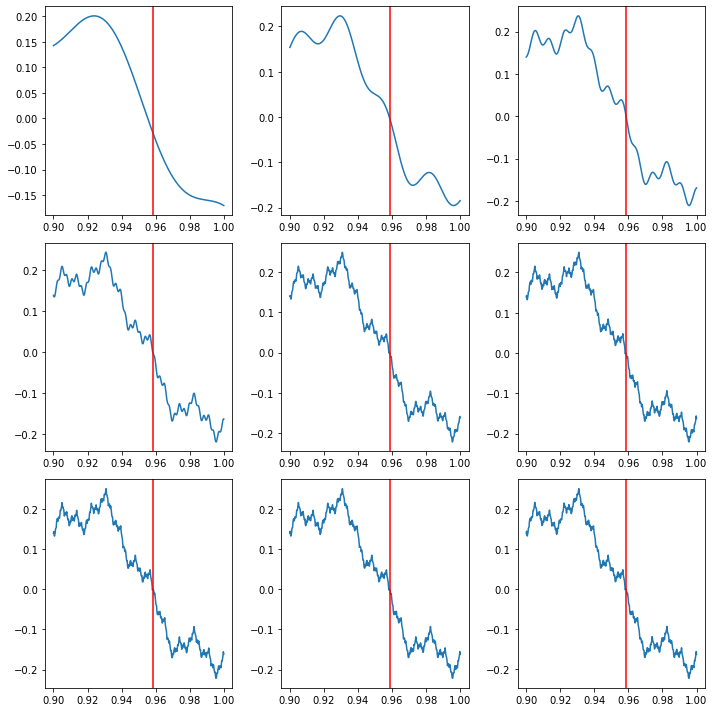

In [46]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flatten(), start=5):
    ax.plot(*F(i))
    #ax.axvline(0.9586621885056955, color="red")
fig.tight_layout()

In [49]:
from math import cos, pi

def f(x, n):
    return sum(cos(3**i*x)/2**i for i in range(n))

In [31]:
from scipy.optimize import root_scalar

In [35]:
def find_root(n):
    res = root_scalar(f, args=(n,), method="bisect", bracket=(0.9, 1.0))
    assert res.converged
    return res.root

In [41]:
roots = [find_root(n) for n in range(5, 64)]

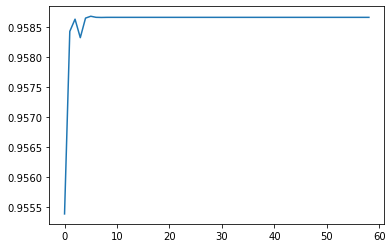

In [42]:
plt.plot(roots)

In [54]:
κ = sum(roots[-5:])/5
κ

0.9586621885056955

In [52]:
from itertools import product

In [64]:
terms = list(range(1, 20))
diffs = {}
for p, q, r, s in product(terms, terms, terms, terms):
    expr = p/q + r/s/pi
    diffs[(p, q, r, s)] = abs(expr - κ)

In [65]:
p, q, r, s = min(diffs, key=diffs.__getitem__)
p, q, r, s

(1, 12, 11, 4)

In [66]:
diffs[(p, q, r, s)]

2.333183306224562e-05

In [68]:
μ = p/q + r/s/pi
μ

0.9586855203387578

In [75]:
f(μ, 50)

9.04256830296561e-05